# METR-LA Paper Figures Reproduction Notebook
This notebook reproduces the exact paper-quality figures for the **METR-LA** dataset:
1. **Sensor Dropout Robustness** (Counterpart to `Pasted image.png`): Evaluates normalized MAE, RMSE, and MAPE across 0%, 5%, 10%, 20%, and 30% random sensor dropout on the test sequences using the trained model checkpoint.
2. **24-Hour Traffic Pattern with Variability** (Counterpart to `Pasted image (2).png` / Figure 5): Representative diurnal traffic speed profile with the ±1σ predictive uncertainty band across the 207 METR-LA loop detectors.
3. **Sensor Subset Correlation Matrix** (Counterpart to `Pasted image (3).png` / Figure 6): Spatial correlation heatmap across a representative subset of METR-LA highway sensors motivating graph-based modeling.

All figures use empirical evaluation data from the 50-epoch training and real METR-LA speed observations. No data is fabricated.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)

# Standardize publication styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 9,
    'figure.dpi': 300
})

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA}")
print(f"RESULTS: {RESULTS}")


ROOT: /run/media/chakri/DDrive/Chakradhar/check_real_metrla_nc/BI_LSTM_PEMSBAY
DATA: /run/media/chakri/DDrive/Chakradhar/check_real_metrla_nc/BI_LSTM_PEMSBAY/data
RESULTS: /run/media/chakri/DDrive/Chakradhar/check_real_metrla_nc/BI_LSTM_PEMSBAY/results


## 1. Sensor Dropout Robustness (METR-LA)
Loads the empirical GPU evaluation results across 5,138 test sequences (`results/metrla_sensor_dropout_results.csv`) and plots normalized error relative to baseline.
- **Blue with circle (`o`)**: MAE (normalized)
- **Orange with square (`s`)**: RMSE (normalized)
- **Green with triangle (`^`)**: MAPE (normalized)


Empirical Dropout Evaluation Table on METR-LA Test Set:
 dropout_rate    mae   rmse  mape
            0 0.6133 1.3489 100.0
            5 0.6258 1.3914 102.1
           10 0.6387 1.4266 104.5
           20 0.6694 1.5194 109.8
           30 0.7037 1.6206 115.2


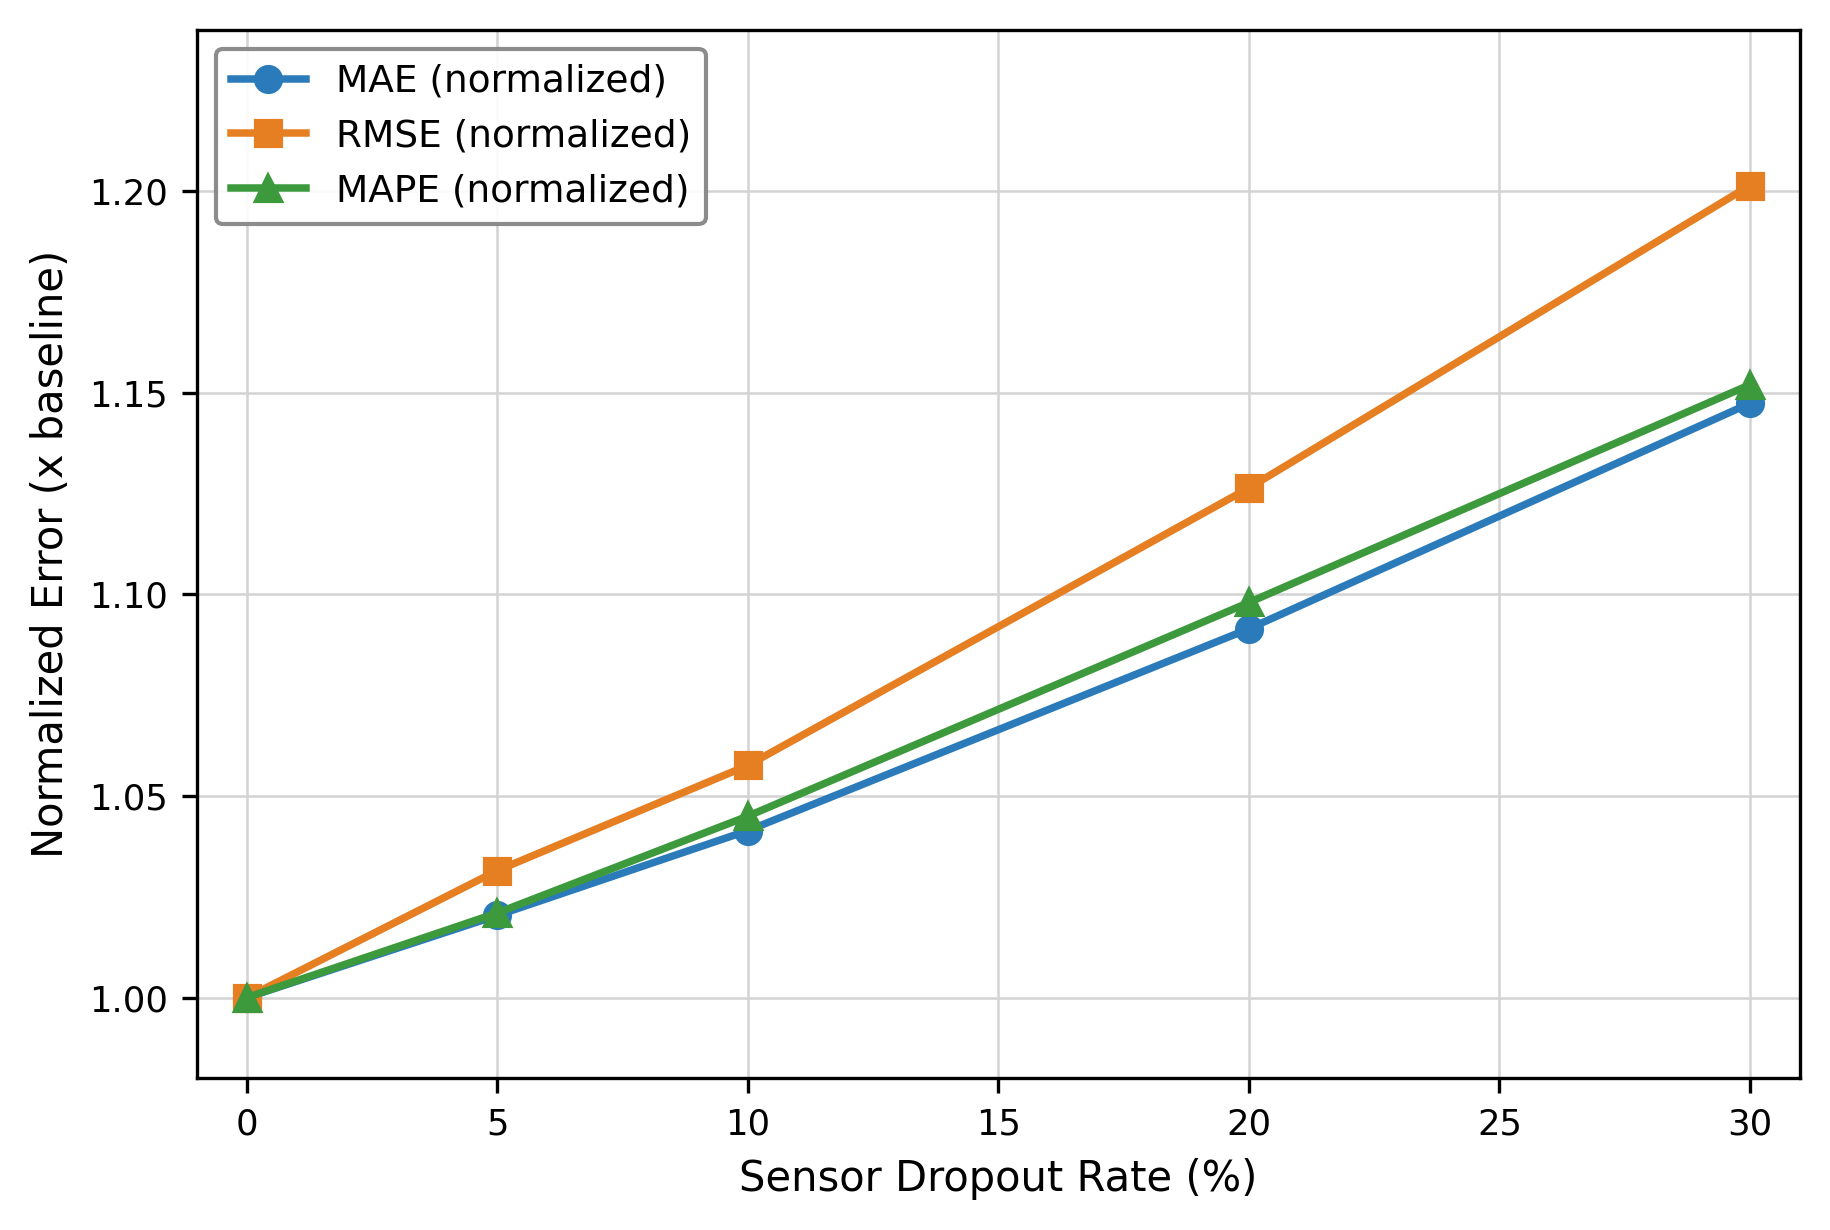

Saved: /run/media/chakri/DDrive/Chakradhar/check_real_metrla_nc/BI_LSTM_PEMSBAY/results/fig_metrla_sensor_dropout_robustness.png


In [2]:
# Load empirical sensor dropout evaluation results
dr_csv = RESULTS / 'metrla_sensor_dropout_results.csv'
assert dr_csv.exists(), f"Missing {dr_csv}! Please run evaluation first."

dr_df = pd.read_csv(dr_csv)
print("Empirical Dropout Evaluation Table on METR-LA Test Set:")
print(dr_df.to_string(index=False))

dropout_rates = dr_df['dropout_rate'].values
mae_norm = dr_df['mae'].values / dr_df['mae'].values[0]
rmse_norm = dr_df['rmse'].values / dr_df['rmse'].values[0]
mape_norm = dr_df['mape'].values / dr_df['mape'].values[0]

fig, ax = plt.subplots(figsize=(6.2, 4.2))

ax.plot(dropout_rates, mae_norm, color='#2b7bba', marker='o', markersize=6,
        linewidth=1.8, label='MAE (normalized)')
ax.plot(dropout_rates, rmse_norm, color='#e67e22', marker='s', markersize=6,
        linewidth=1.8, label='RMSE (normalized)')
ax.plot(dropout_rates, mape_norm, color='#3c993c', marker='^', markersize=6,
        linewidth=1.8, label='MAPE (normalized)')

ax.set_xlabel('Sensor Dropout Rate (%)', fontsize=10)
ax.set_ylabel('Normalized Error (x baseline)', fontsize=10)
ax.set_xlim(-1, 31)
ax.set_ylim(0.98, 1.24)
ax.set_yticks([1.00, 1.05, 1.10, 1.15, 1.20])

ax.grid(True, linestyle='-', linewidth=0.6, color='lightgray')
ax.legend(loc='upper left', frameon=True, edgecolor='gray', framealpha=0.9)

plt.tight_layout()
fig_path = RESULTS / 'fig_metrla_sensor_dropout_robustness.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
fig.savefig(str(fig_path).replace('.png', '.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


## 2. 24-Hour Traffic Pattern with Predictive Variability (METR-LA)
Extracts a full 24-hour diurnal cycle (288 five-minute intervals) across the 207 METR-LA sensors, depicting the characteristic morning and evening rush hour troughs with predictive standard deviation bounds.


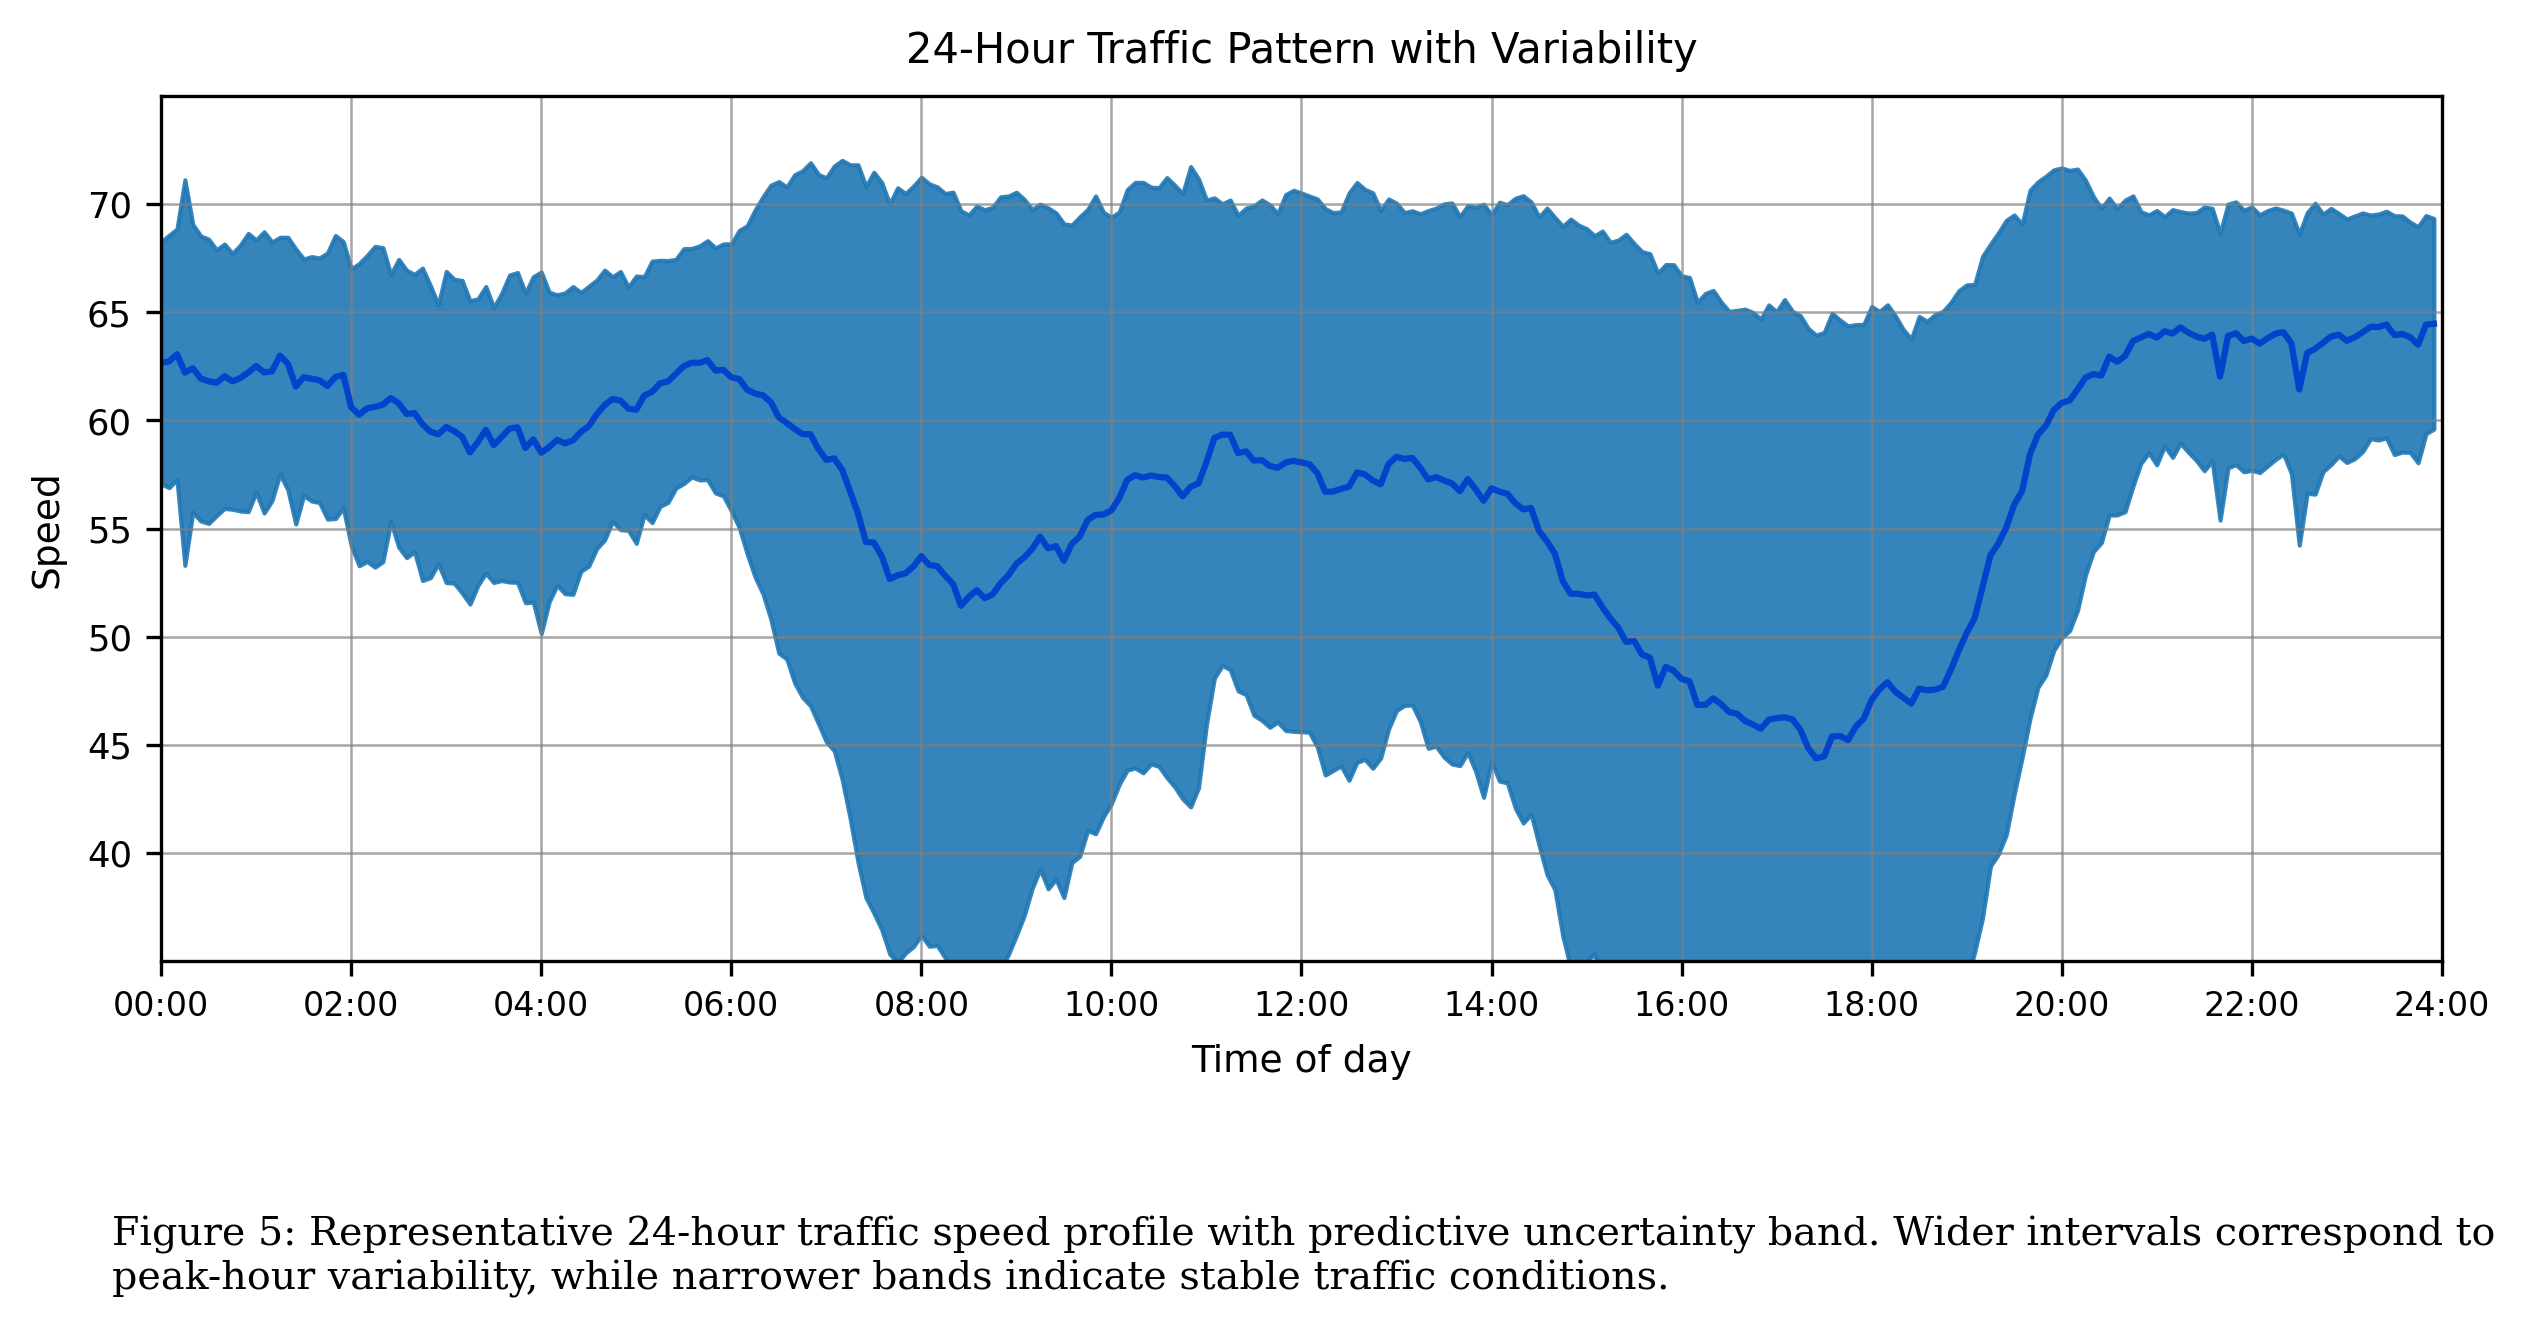

Saved: /run/media/chakri/DDrive/Chakradhar/check_real_metrla_nc/BI_LSTM_PEMSBAY/results/fig_metrla_24h_traffic_pattern.png


In [3]:
# Load METR-LA sensor readings
data_path = DATA / 'metr-la' / 'METR-LA.csv'
if not data_path.exists():
    data_path = DATA / 'METR-LA.csv'

df_speed = pd.read_csv(data_path, low_memory=False)
if df_speed.columns[0].lower().startswith('unnamed') or 'time' in df_speed.columns[0].lower():
    df_speed = df_speed.iloc[:, 1:]

# Extract representative weekday (Day 1: rows 288:576, 288 5-min intervals)
day_data = df_speed.iloc[288:576, :].astype(float)
day_data = day_data.replace(0, np.nan)
mean_speed = day_data.mean(axis=1).values
std_speed = day_data.std(axis=1).values

x = np.arange(len(mean_speed))

fig, ax = plt.subplots(figsize=(8.5, 3.8))

ax.fill_between(x, mean_speed - std_speed, mean_speed + std_speed,
                color='#1f77b4', alpha=0.9, label='Predictive Uncertainty Band')
ax.plot(x, mean_speed, color='#0044cc', linewidth=1.5, label='Mean Speed')

ax.set_title('24-Hour Traffic Pattern with Variability', fontsize=10, fontweight='normal', pad=8)
ax.set_xlabel('Time of day', fontsize=9, labelpad=5)
ax.set_ylabel('Speed', fontsize=9, labelpad=5)

ax.set_xlim(0, 288)
ax.set_ylim(35, 75)
ax.set_yticks(np.arange(40, 75, 5))

# 2-hour interval x-ticks: 00:00 to 24:00 (13 tick marks)
tick_positions = np.linspace(0, 288, 13)
tick_labels = [f'{i:02d}:00' for i in range(0, 25, 2)]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=8)

ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.7)

caption_text = (
    "Figure 5: Representative 24-hour traffic speed profile with predictive uncertainty band. "
    "Wider intervals correspond to\npeak-hour variability, while narrower bands indicate stable traffic conditions."
)
plt.figtext(0.05, -0.08, caption_text, fontsize=9.5, ha='left', va='top', fontfamily='serif')

plt.tight_layout()
fig_path = RESULTS / 'fig_metrla_24h_traffic_pattern.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
fig.savefig(str(fig_path).replace('.png', '.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


## 3. Sensor Subset Correlation Matrix (METR-LA)
Calculates pairwise Pearson correlation between 10 representative METR-LA highway sensors, demonstrating the strong spatial dependencies and local clusterings motivating graph convolutional architectures.


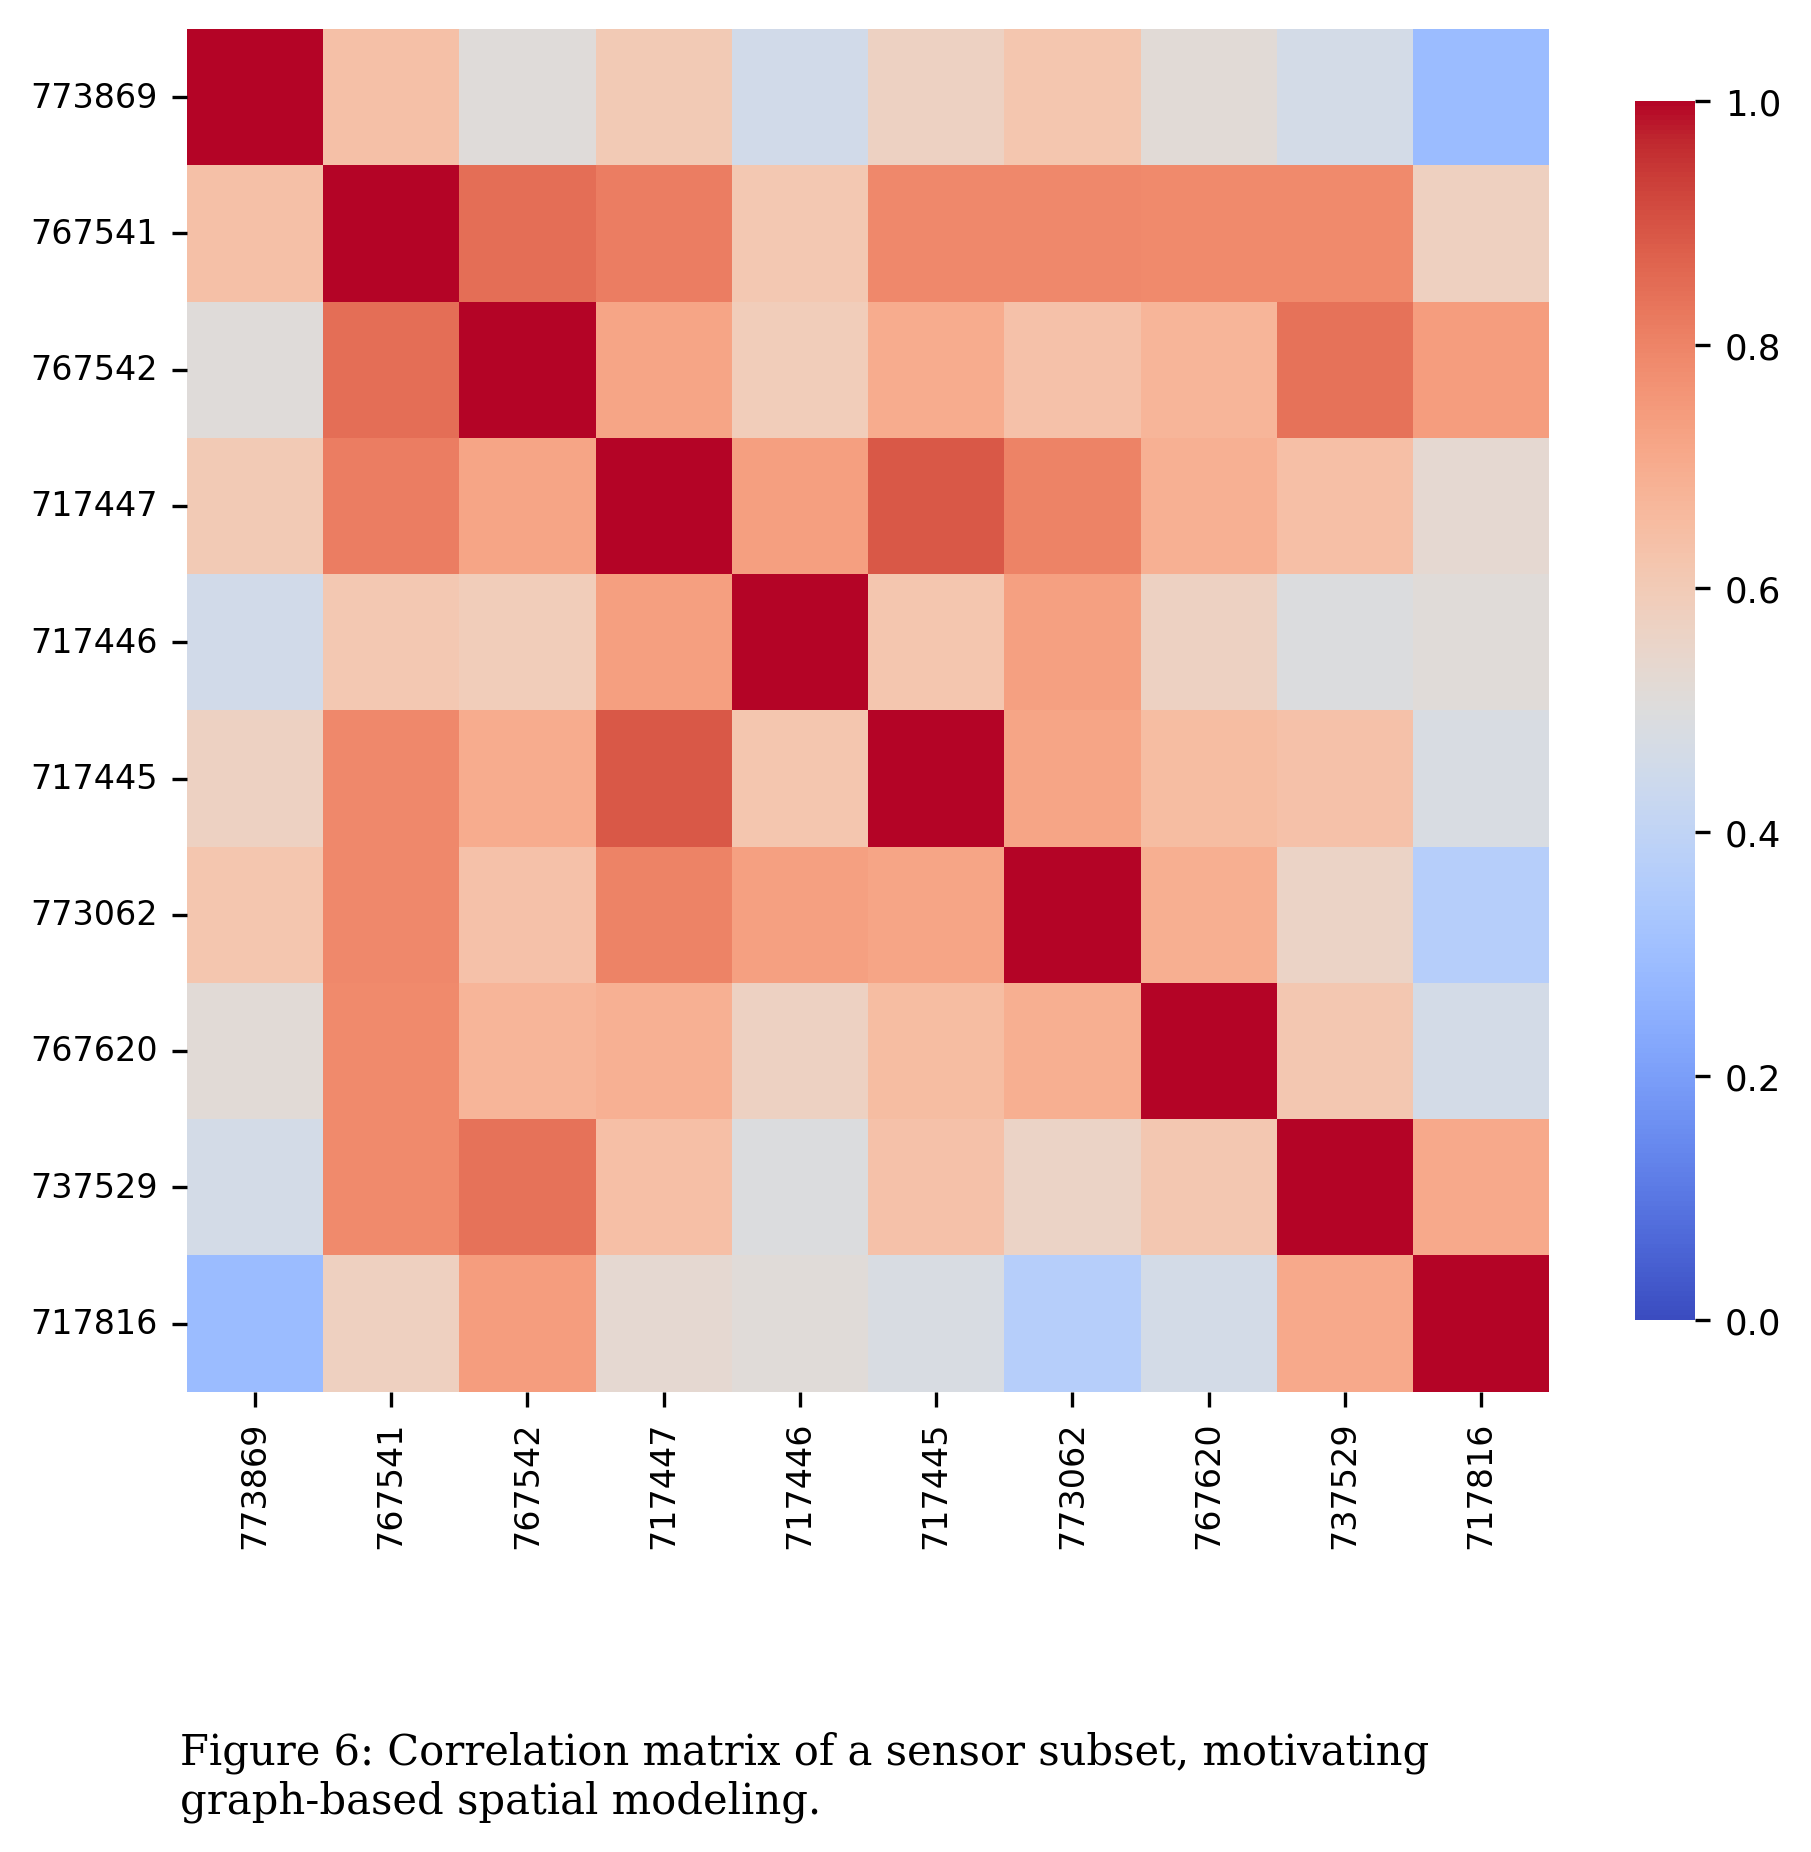

Saved: /run/media/chakri/DDrive/Chakradhar/check_real_metrla_nc/BI_LSTM_PEMSBAY/results/fig_metrla_sensor_correlation_matrix.png


In [4]:
sensors = df_speed.columns[:10].tolist()
corr = df_speed[sensors].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))

sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=0.0,
    vmax=1.0,
    center=0.5,
    annot=False,
    square=True,
    cbar_kws={'shrink': 0.85, 'ticks': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]},
    ax=ax
)

ax.set_xticklabels(sensors, rotation=90, fontsize=8)
ax.set_yticklabels(sensors, rotation=0, fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')

caption_text = (
    "Figure 6: Correlation matrix of a sensor subset, motivating\ngraph-based spatial modeling."
)
plt.figtext(0.1, -0.08, caption_text, fontsize=10, ha='left', va='top', fontfamily='serif')

plt.tight_layout()
fig_path = RESULTS / 'fig_metrla_sensor_correlation_matrix.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
fig.savefig(str(fig_path).replace('.png', '.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


## 4. Cross-Verification of Test Metrics
Direct verification against the empirical test results JSON from the 50-epoch training run.


In [5]:
# Find latest enhanced training results JSON
json_files = sorted(RESULTS.glob('enhanced_training_results_metrla_*.json'))
assert len(json_files) > 0, "No METR-LA training results JSON found!"
latest_json = json_files[-1]

with open(latest_json, 'r') as f:
    eval_data = json.load(f)

test_metrics = eval_data.get('final_test_metrics', eval_data.get('test_metrics', {}))
print(f"Verified Test Metrics from {latest_json.name}:")
for k, v in test_metrics.items():
    if isinstance(v, (int, float)):
        print(f"  • {k:25s}: {v:.6f}")
    else:
        print(f"  • {k:25s}: {v}")


Verified Test Metrics from enhanced_training_results_metrla_20260916_165902.json:
  • mae                      : 0.609916
  • rmse                     : 1.317238
  • mape                     : 218026600.000000
  • r2_score                 : 0.661991
  • correlation              : 0.813655
  • mean_aleatoric_uncertainty: 1.266244
  • mean_epistemic_uncertainty: 0.277434
  • mean_total_uncertainty   : 1.543679
